In [1]:
import os

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

In [2]:
from datasets import load_dataset, Image

dataset = load_dataset("AI-Lab-Makerere/beans", split="train")

d:\miniconda3\envs\PyTorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\miniconda3\envs\PyTorch\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in E:\huggingface\datasets--AI-Lab-Makerere--beans. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://d

In [3]:
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 1034
})

In [4]:
dataset[0]

{'image_file_path': '/home/albert/.cache/huggingface/datasets/downloads/extracted/967f0d9f61a7a8de58892c6fab6f02317c06faf3e19fba6a07b0885a9a7142c7/train/angular_leaf_spot/angular_leaf_spot_train.0.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500>,
 'labels': 0}

In [6]:
dataset = dataset.cast_column("image", Image(mode="RGB"))
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 1034
})

In [11]:
dataset[0]

{'image_file_path': '/home/albert/.cache/huggingface/datasets/downloads/extracted/967f0d9f61a7a8de58892c6fab6f02317c06faf3e19fba6a07b0885a9a7142c7/train/angular_leaf_spot/angular_leaf_spot_train.0.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500>,
 'labels': 0}

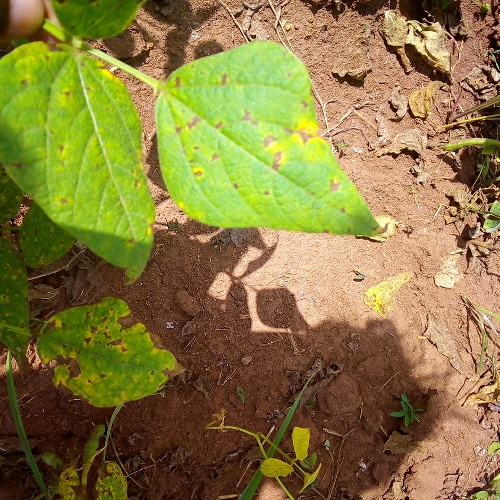

In [12]:
dataset[0]['image']

In [13]:
from torchvision.transforms import Compose, ColorJitter, ToTensor

jitter = Compose(
    [ColorJitter(brightness=0.5, hue=0.5), ToTensor()]
)

In [14]:
def transforms(examples):
    examples["pixel_values"] = [jitter(image.convert("RGB")) for image in examples["image"]]
    return examples

In [58]:
dataset = dataset.with_transform(transforms)
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 1034
})

In [59]:
dataset[0]

{'image_file_path': '/home/albert/.cache/huggingface/datasets/downloads/extracted/967f0d9f61a7a8de58892c6fab6f02317c06faf3e19fba6a07b0885a9a7142c7/train/angular_leaf_spot/angular_leaf_spot_train.0.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500>,
 'labels': 0,
 'pixel_values': tensor([[[0.0471, 0.0471, 0.0471,  ..., 0.7765, 0.0196, 0.0000],
          [0.0353, 0.0431, 0.0431,  ..., 0.6000, 0.2078, 0.0000],
          [0.0392, 0.0392, 0.0510,  ..., 0.6000, 0.2314, 0.1490],
          ...,
          [0.1020, 0.0549, 0.1020,  ..., 0.9176, 0.8824, 0.9294],
          [0.0667, 0.0627, 0.1647,  ..., 0.9137, 0.9255, 0.9098],
          [0.1137, 0.0902, 0.0431,  ..., 0.8980, 0.9137, 0.9294]],
 
         [[0.0078, 0.0078, 0.0078,  ..., 0.7765, 0.1412, 0.1373],
          [0.0000, 0.0039, 0.0039,  ..., 0.6824, 0.3176, 0.1294],
          [0.0000, 0.0039, 0.0078,  ..., 0.6471, 0.3098, 0.2157],
          ...,
          [0.1725, 0.1333, 0.1725,  ..., 0.5961, 0.6784, 0.5569],

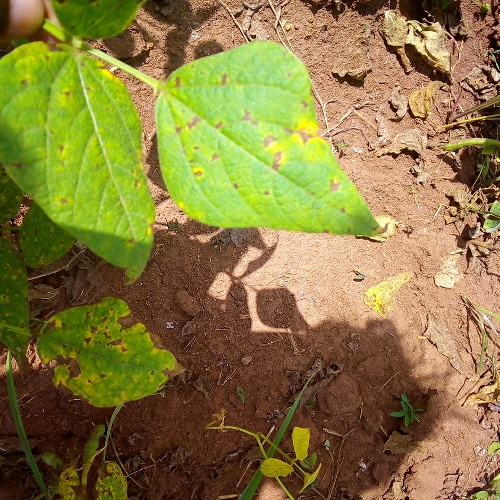

In [60]:
dataset[0]['image']

In [61]:
from torch.utils.data import DataLoader

def collate_fn(examples):
    images = []
    labels = []
    for example in examples:
        images.append((example["pixel_values"]))
        labels.append(example["labels"])
    pixel_values = torch.stack(images)
    labels = torch.tensor(labels)
    return {"pixel_values": pixel_values, "labels": labels}

dataloader = DataLoader(dataset, collate_fn=collate_fn, batch_size=4)

In [34]:
import torch

for datas in dataloader:
    # print(datas['pixel_values'])
    for data_pixel_value in datas['pixel_values']:
        print(data_pixel_value)
        break
    # print(datas['labels'])
    for data_label in datas['labels']:
        print(data_label)
        break
    break

tensor([[[0.1765, 0.1765, 0.1765,  ..., 0.6431, 0.2078, 0.1686],
         [0.1686, 0.1725, 0.1725,  ..., 0.5373, 0.3098, 0.1647],
         [0.1569, 0.1608, 0.1608,  ..., 0.5373, 0.3255, 0.2667],
         ...,
         [0.1765, 0.1490, 0.1804,  ..., 0.4549, 0.4980, 0.4314],
         [0.1569, 0.1529, 0.2157,  ..., 0.4863, 0.4588, 0.4824],
         [0.1804, 0.1686, 0.1490,  ..., 0.4353, 0.4902, 0.4667]],

        [[0.1294, 0.1294, 0.1294,  ..., 0.5020, 0.0667, 0.0235],
         [0.1216, 0.1255, 0.1255,  ..., 0.4118, 0.1725, 0.0314],
         [0.1137, 0.1216, 0.1216,  ..., 0.4314, 0.2078, 0.1569],
         ...,
         [0.0863, 0.0627, 0.0941,  ..., 0.5647, 0.6078, 0.5412],
         [0.0706, 0.0667, 0.1294,  ..., 0.5843, 0.5490, 0.5725],
         [0.0941, 0.0824, 0.0627,  ..., 0.5216, 0.5686, 0.5490]],

        [[0.0039, 0.0039, 0.0039,  ..., 0.4235, 0.0118, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.3255, 0.1137, 0.0000],
         [0.0000, 0.0000, 0.0039,  ..., 0.3255, 0.1255, 0.

In [62]:
for datas in dataloader:
    for data_pixel_value in datas['pixel_values']:
        data_pixel_value
        break
    break

data_pixel_value.shape, type(data_pixel_value), data_pixel_value.permute(1, 2, 0).shape

(torch.Size([3, 500, 500]), torch.Tensor, torch.Size([500, 500, 3]))

In [63]:
import numpy as np
from PIL import Image
def tensor_to_pil(img_tensor):
    """
    把 PyTorch 图片张量转为 PIL 图像
    :param img_tensor: 形状 [C, H, W]，值范围 [0, 1] 或 [-1, 1]
    :return: PIL.Image 对象
    """
    # 步骤1：处理归一化（若张量值范围是 [-1, 1]，需反归一化到 [0, 1]）
    if img_tensor.min() < 0:
        img_tensor = (img_tensor + 1) / 2  # [-1,1] → [0,1]
    
    # 步骤2：通道转换 [C, H, W] → [H, W, C]，并转为 NumPy 数组
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy() # 若在GPU上需先.cpu()

    # 步骤3：值范围转换 [0, 1] → [0, 255]，并转为 uint8 格式
    img_np = (img_np * 255).astype(np.uint8)
    
    # 步骤4：转为 PIL 图像
    pil_img = Image.fromarray(img_np)
    return pil_img

pil_img_from_tensor = tensor_to_pil(data_pixel_value)
pil_img_from_tensor.show()